Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Utworzono folder na wykresy: /content/drive/MyDrive/Magisterka_wykresy/results_20260707_124848

Zapisano wykres: /content/drive/MyDrive/Magisterka_wykresy/results_20260707_124848/1_Zagregowana_Skutecznosc.png


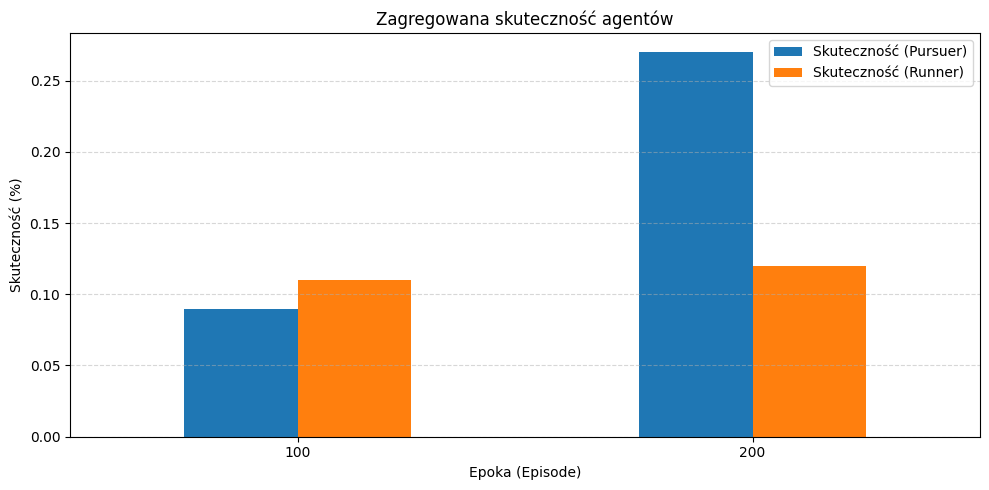

Zapisano wykres: /content/drive/MyDrive/Magisterka_wykresy/results_20260707_124848/2_Plynnosc_Ruchu_Jitter.png


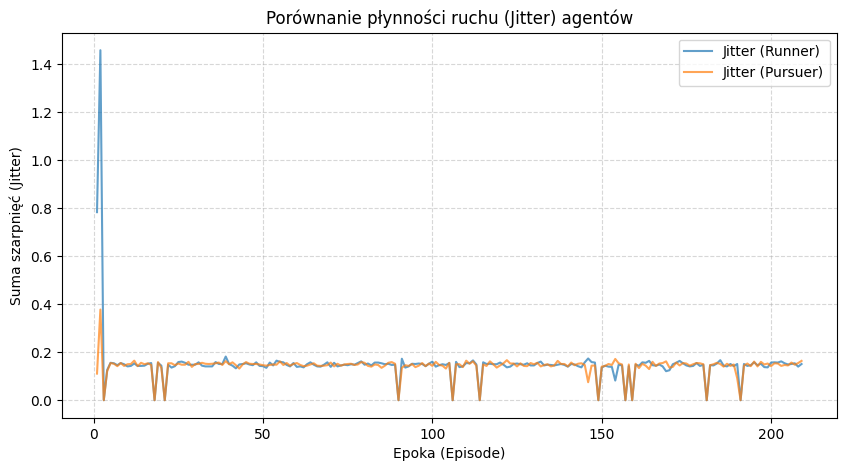

Zapisano wykres: /content/drive/MyDrive/Magisterka_wykresy/results_20260707_124848/3_Bliskie_Spotkania_NearMisses.png


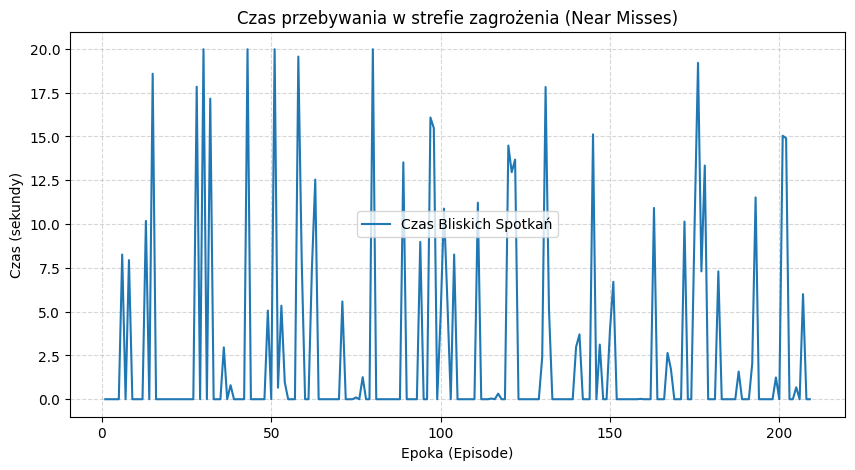

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime

def plot_aggregated_accuracy(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    ax = df.plot(x='Episode', y=['Pursuer Accuracy', 'Runner Accuracy'], kind='bar', figsize=(10, 5))

    plt.title('Zagregowana skuteczność agentów')
    plt.xlabel('Epoka (Episode)')
    plt.ylabel('Skuteczność (%)')

    plt.legend(['Skuteczność (Pursuer)', 'Skuteczność (Runner)'])

    plt.grid(True, linestyle='--', alpha=0.5, axis='y')

    plt.xticks(rotation=0)

    plt.tight_layout()

    save_path = os.path.join(save_dir, '1_Zagregowana_Skutecznosc.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Zapisano wykres: {save_path}")

    plt.show()


def plot_jitter(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Episode'], df['RunnerJitter'], label='Jitter (Runner)', alpha=0.7)
    plt.plot(df['Episode'], df['PursuerJitter'], label='Jitter (Pursuer)', alpha=0.7)

    plt.title('Porównanie płynności ruchu (Jitter) agentów')
    plt.xlabel('Epoka (Episode)')
    plt.ylabel('Suma szarpnięć (Jitter)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    save_path = os.path.join(save_dir, '2_Plynnosc_Ruchu_Jitter.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Zapisano wykres: {save_path}")

    plt.show()


def plot_near_misses(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Episode'], df['NearMissTime'], label='Czas Bliskich Spotkań')

    plt.title('Czas przebywania w strefie zagrożenia (Near Misses)')
    plt.xlabel('Epoka (Episode)')
    plt.ylabel('Czas (sekundy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    save_path = os.path.join(save_dir, '3_Bliskie_Spotkania_NearMisses.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Zapisano wykres: {save_path}")

    plt.show()


if __name__ == "__main__":
    results = "results_20260707_142320.csv"
    agg_results = "Aggregated_results_20260707_142320.csv"

    try:
        from google.colab import drive
        drive.mount('/content/drive')

        base_dir = '/content/drive/MyDrive/Magisterka_wykresy'
    except ImportError:
        print("Nie wykryto środowiska Google Colab. Pliki zostaną zapisane lokalnie.")
        base_dir = 'Magisterka_wykresy'

    try:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        folder_name = os.path.join(base_dir, f"results_{timestamp}")

        os.makedirs(folder_name, exist_ok=True)
        print(f"Utworzono folder na wykresy: {folder_name}\n")

        plot_aggregated_accuracy(agg_results, folder_name)
        plot_jitter(results, folder_name)
        plot_near_misses(results, folder_name)
    except FileNotFoundError as e:
        print(f"Error: file not found. Details: {e}")